## Import Libraries

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Define Image Processing Function

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
# Embedded production constants and helpers (copied verbatim where applicable)
ROI_SHRINK_RATIO = 0.12
def _load_and_validate_image(file_bytes):
    """Validate TIFF grayscale input and normalize any 16-bit NumPy dtype to uint16."""
    try:
        pil_img = Image.open(io.BytesIO(file_bytes))
    except Exception as exc:
        raise ValueError(f"Image format validation failed: unable to read image bytes ({exc}).") from exc

    img_format = (pil_img.format or "unknown").upper()
    if img_format != "TIFF":
        raise ValueError(
            f"Image format validation failed: expected 16-bit grayscale TIFF, got format '{img_format}'."
        )

    img = np.array(pil_img)
    if img.ndim != 2:
        raise ValueError(
            f"Image format validation failed: expected grayscale TIFF (single channel), got shape {img.shape}."
        )
    if img.dtype.kind != "u" or img.dtype.itemsize != 2:
        raise ValueError(
            f"Image format validation failed: expected 16-bit grayscale TIFF, got dtype '{img.dtype}'."
        )
    return img.astype(np.uint16, copy=False)
def _shrink_box(box, ratio=ROI_SHRINK_RATIO):
    box_arr = np.array(box, dtype=np.float32)
    center = np.mean(box_arr, axis=0, keepdims=True)
    shrunk = center + (box_arr - center) * (1.0 - float(ratio))
    return shrunk.astype(np.int32)
def _mean_intensity_in_box(img_16bit, box, shrink_ratio=ROI_SHRINK_RATIO):
    mask = np.zeros_like(img_16bit, dtype=np.uint8)
    shrunk_box = _shrink_box(box, shrink_ratio)
    cv2.drawContours(mask, [np.array(shrunk_box, dtype=np.int32)], 0, 255, -1)
    pixel_values = img_16bit[mask == 255]
    if len(pixel_values) == 0:
        raise ValueError("ROI validation failed: no pixels inside shrunken ROI.")
    return float(np.mean(pixel_values)), pixel_values
def process_image(
    image_path,
    threshold_value=24000,
    min_area=2000,
    max_area=100000,
    min_circularity=0.6,
    min_solidity=0.7,
    min_aspect_ratio=0.7,
    max_aspect_ratio=1.3,
    expected_count=4,
    grid_cols=4,
    return_data=False,
):
    """
    Deteksi lingkaran dalam gambar 16-bit dengan validasi bentuk yang lebih ketat.
    """
    # 1. Load Gambar 16-bit (embedded production loader)
    try:
        with open(image_path, "rb") as _f:
            _bytes = _f.read()
        img_16bit = _load_and_validate_image(_bytes)
    except Exception as exc:
        print(f"Error: Gambar tidak ditemukan atau tidak valid TIFF (\n{exc}).")
        return None if return_data else None
    print(f"Dimensi Gambar: {img_16bit.shape}")
    # 2. Thresholding
    binary_mask = np.zeros_like(img_16bit, dtype=np.uint8)
    binary_mask[img_16bit < threshold_value] = 255
    # Bersihkan noise kecil menggunakan morfologi
    kernel = np.ones((5, 5), np.uint8)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=2)
    # 3. Cari Kontur
    contours, _ = cv2.findContours(
        binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    valid_circles = []
    print(f"Jumlah kontur awal ditemukan: {len(contours)}")
    # 4. Filter kontur dengan validasi bentuk yang lebih ketat
    for cnt in contours:
        area = cv2.contourArea(cnt)
        # Filter 1: Area
        if area < min_area or area > max_area:
            continue
        # Hitung properties dasar
        (x, y), radius = cv2.minEnclosingCircle(cnt)
        center = (int(x), int(y))
        radius = int(radius)
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue
        # Filter 2: Circularity (kebulatan)
        circularity = 4 * np.pi * (area / (perimeter * perimeter))
        if circularity < min_circularity:
            continue
        # Filter 3: Solidity (mengecek jika objek berlubang atau tidak solid)
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        if hull_area == 0:
            continue
        solidity = area / hull_area
        if solidity < min_solidity:
            continue
        # Filter 4: Aspect Ratio (mengecek jika terlalu oval)
        rect = cv2.minAreaRect(cnt)
        width, height = rect[1]
        if width == 0 or height == 0:
            continue
        aspect_ratio = max(width, height) / min(width, height)
        if aspect_ratio < min_aspect_ratio or aspect_ratio > max_aspect_ratio:
            continue
        # Semua filter passed - simpan circle
        valid_circles.append(
            {
                "center": center,
                "radius": radius,
                "contour": cnt,
                "area": area,
                "circularity": circularity,
                "solidity": solidity,
                "aspect_ratio": aspect_ratio,
            }
        )
    print(f"Setelah filtering bentuk: {len(valid_circles)} objek valid")
    # 5. Filter duplikat berdasarkan jarak
    if len(valid_circles) > expected_count:
        # Hapus lingkaran yang terlalu dekat (duplikat)
        filtered = []
        for i, circle in enumerate(valid_circles):
            is_duplicate = False
            for j, other in enumerate(filtered):
                # Hitung jarak antar center
                dist = np.sqrt((circle["center"][0] - other["center"][0]) ** 2 + (circle["center"][1] - other["center"][1]) ** 2)
                # Jika jarak < rata-rata radius, anggap duplikat
                avg_radius = (circle["radius"] + other["radius"]) / 2
                if dist < avg_radius * 0.8:
                    is_duplicate = True
                    # Pilih yang circularity lebih tinggi
                    if circle["circularity"] > other["circularity"]:
                        filtered[j] = circle
                    break
            if not is_duplicate:
                filtered.append(circle)
        valid_circles = filtered
        print(f"Setelah hapus duplikat: {len(valid_circles)} objek")
    # 6. Sorting Grid dengan Row Clustering
    if len(valid_circles) >= expected_count:
        # Sort berdasarkan Y dulu
        valid_circles.sort(key=lambda c: c["center"][1])
        # Cluster ke dalam baris menggunakan K-means sederhana pada Y
        num_rows = expected_count // grid_cols
        sorted_final = []
        for row_idx in range(num_rows):
            start_idx = row_idx * grid_cols
            end_idx = start_idx + grid_cols
            if end_idx <= len(valid_circles):
                row = valid_circles[start_idx:end_idx]
                row.sort(key=lambda c: c["center"][0])
                sorted_final.extend(row)
        if len(sorted_final) == expected_count:
            valid_circles = sorted_final
        else:
            valid_circles.sort(key=lambda c: (c["center"][1] // 200, c["center"][0]))
    else:
        valid_circles.sort(key=lambda c: (c["center"][1] // 200, c["center"][0]))
    # 7. Visualisasi & Klasifikasi
    img_display = cv2.normalize(img_16bit, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
    img_rgb = cv2.cvtColor(img_display, cv2.COLOR_GRAY2RGB)
    debug_mask_rgb = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2RGB)
    print("\n--- Data Deteksi Final ---")
    print(f"{'No':<4} | {'Posisi':<15} | {'R':<5} | {'Mean':<8} | {'Circ':<6} | {'Solid':<6} | {'AR':<6} | {'Class'}")
    print("-" * 85)
    results = []
    for i, item in enumerate(valid_circles):
        center = item["center"]
        radius = item["radius"]
        # Ambil nilai rata-rata pixel asli (16-bit) di dalam *shrunken* area lingkaran
        shrunk_radius = max(1, int(radius * (1.0 - ROI_SHRINK_RATIO)))
        mask_sampling = np.zeros_like(img_16bit, dtype=np.uint8)
        cv2.circle(mask_sampling, center, shrunk_radius, 255, -1)
        pixel_values = img_16bit[mask_sampling == 255]
        if pixel_values.size == 0:
            mean_val = float('nan')
        else:
            mean_val = float(np.mean(pixel_values))
        # Klasifikasi Warna
        if mean_val < 6000:
            label = "Hitam"
            color = (255, 0, 0)  # Merah
        else:
            label = "Abu-abu"
            color = (0, 255, 0)  # Hijau
        # Gambar di Output
        cv2.circle(img_rgb, center, radius, color, 4)
        cv2.putText(img_rgb, str(i + 1), (center[0] - 20, center[1] + 10), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 100, 255), 4)
        # Gambar di Mask Debug
        cv2.circle(debug_mask_rgb, center, radius, (0, 0, 255), 4)
        cv2.putText(debug_mask_rgb, str(i + 1), (center[0] - 20, center[1] + 10), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 100, 255), 4)
        # Simpan hasil
        result_item = {
            "id": i + 1,
            "center": center,
            "radius": radius,
            "mean_value": mean_val,
            "classification": label,
            "circularity": item["circularity"],
            "solidity": item["solidity"],
            "aspect_ratio": item["aspect_ratio"],
        }
        results.append(result_item)
        print(f"{i+1:<4} | {str(center):<15} | {radius:<5} | {mean_val:<8.1f} | {item['circularity']:<6.3f} | {item['solidity']:<6.3f} | {item['aspect_ratio']:<6.3f} | {label}")
    # Tampilkan visualisasi
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    ax[0].imshow(img_rgb)
    ax[0].set_title(f"Hasil Deteksi ({len(valid_circles)} Objek)")
    ax[0].axis("off")
    ax[1].imshow(debug_mask_rgb)
    ax[1].set_title(f"Masking Threshold < {threshold_value} (Cek kebersihan mask ini)")
    ax[1].axis("off")
    plt.tight_layout()
    plt.show()
    # Return data jika diminta
    if return_data:
        return {
            "circles": results,
            "image_rgb": img_rgb,
            "mask": binary_mask,
            "count": len(results),
        }

## Process Image

Specify the image file path and run the processing function.

Dimensi Gambar: (2048, 2448)
Jumlah kontur awal ditemukan: 4
Setelah filtering bentuk: 4 objek valid

--- Data Deteksi Final ---
No   | Posisi          | R     | Mean     | Circ   | Solid  | AR     | Class
-------------------------------------------------------------------------------------
1    | (514, 1745)     | 156   | 1539.4   | 0.825  | 0.989  | 1.013  | Hitam
2    | (972, 1291)     | 160   | 2085.3   | 0.855  | 0.991  | 1.003  | Hitam
3    | (1448, 815)     | 162   | 2850.2   | 0.854  | 0.991  | 1.013  | Hitam
4    | (1905, 361)     | 157   | 3207.4   | 0.827  | 0.989  | 1.030  | Hitam


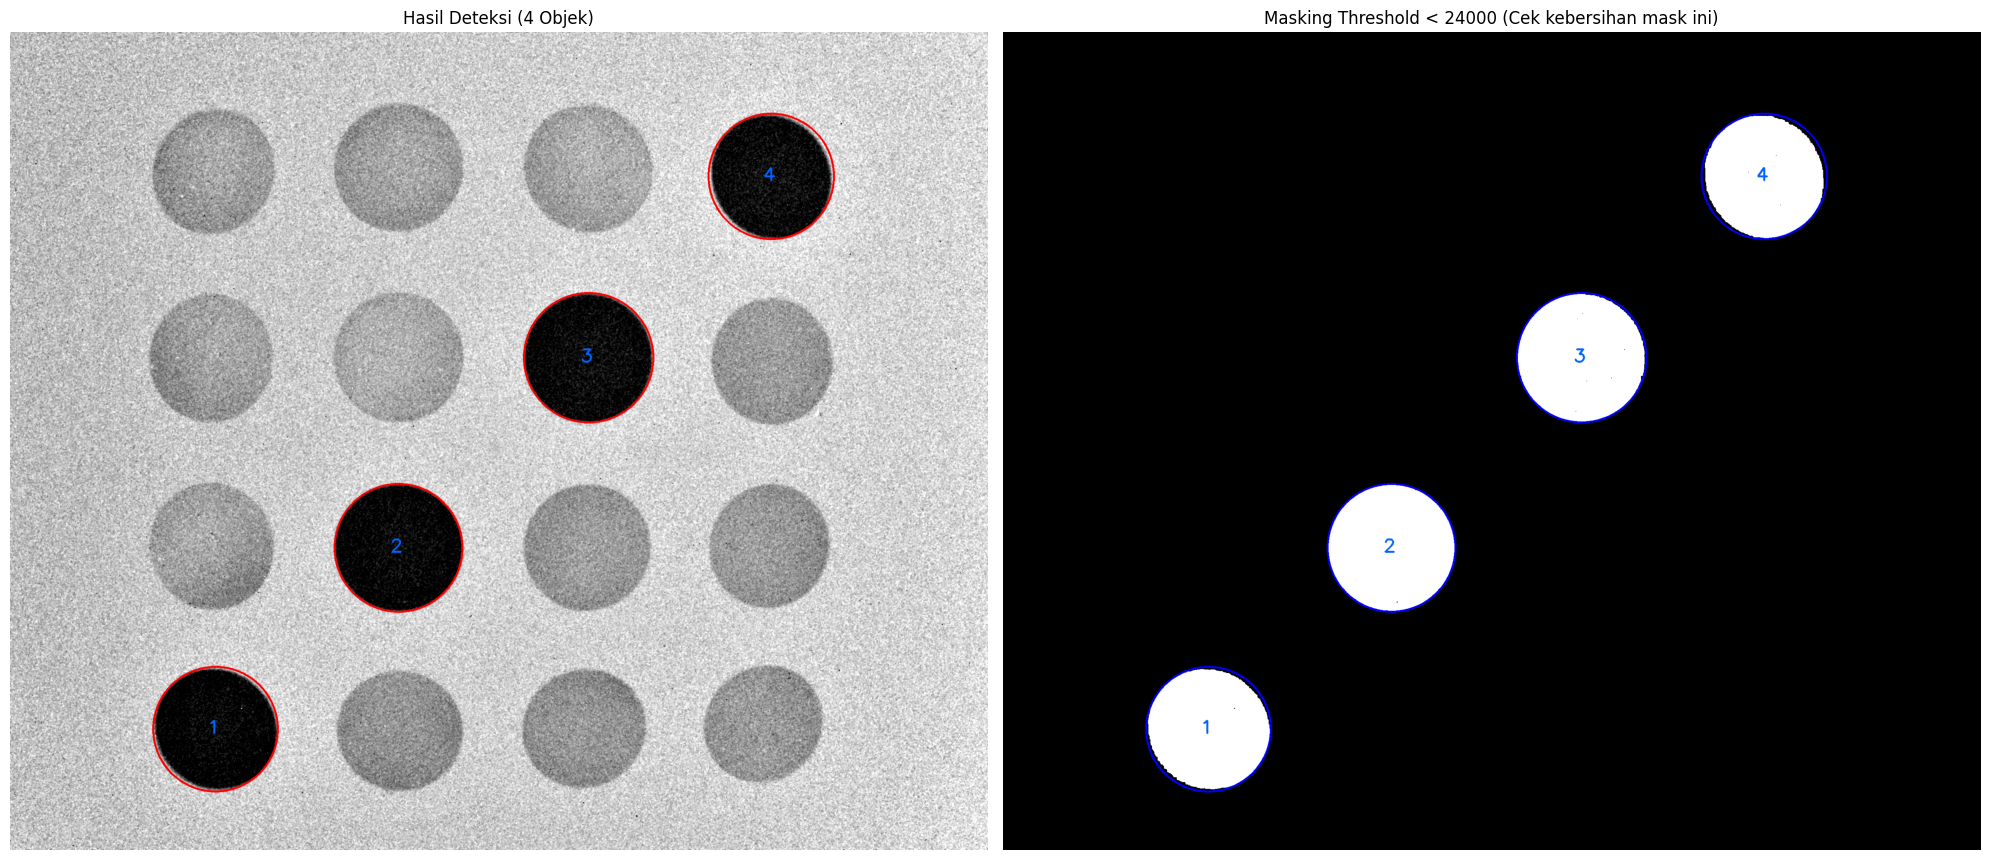

In [9]:
image_file = r"sample-circle.tiff"
process_image(image_file)

## Detect Full Grid Based on Diagonal Pattern

This section checks if detected circles form a diagonal pattern, then uses their positions and radii to predict and detect all circles in a 4x4 grid.

Dimensi Gambar: (2048, 2448)
Jumlah kontur awal ditemukan: 4
Setelah filtering bentuk: 4 objek valid

--- Data Deteksi Final ---
No   | Posisi          | R     | Mean     | Circ   | Solid  | AR     | Class
-------------------------------------------------------------------------------------
1    | (514, 1745)     | 156   | 1539.4   | 0.825  | 0.989  | 1.013  | Hitam
2    | (972, 1291)     | 160   | 2085.3   | 0.855  | 0.991  | 1.003  | Hitam
3    | (1448, 815)     | 162   | 2850.2   | 0.854  | 0.991  | 1.013  | Hitam
4    | (1905, 361)     | 157   | 3207.4   | 0.827  | 0.989  | 1.030  | Hitam


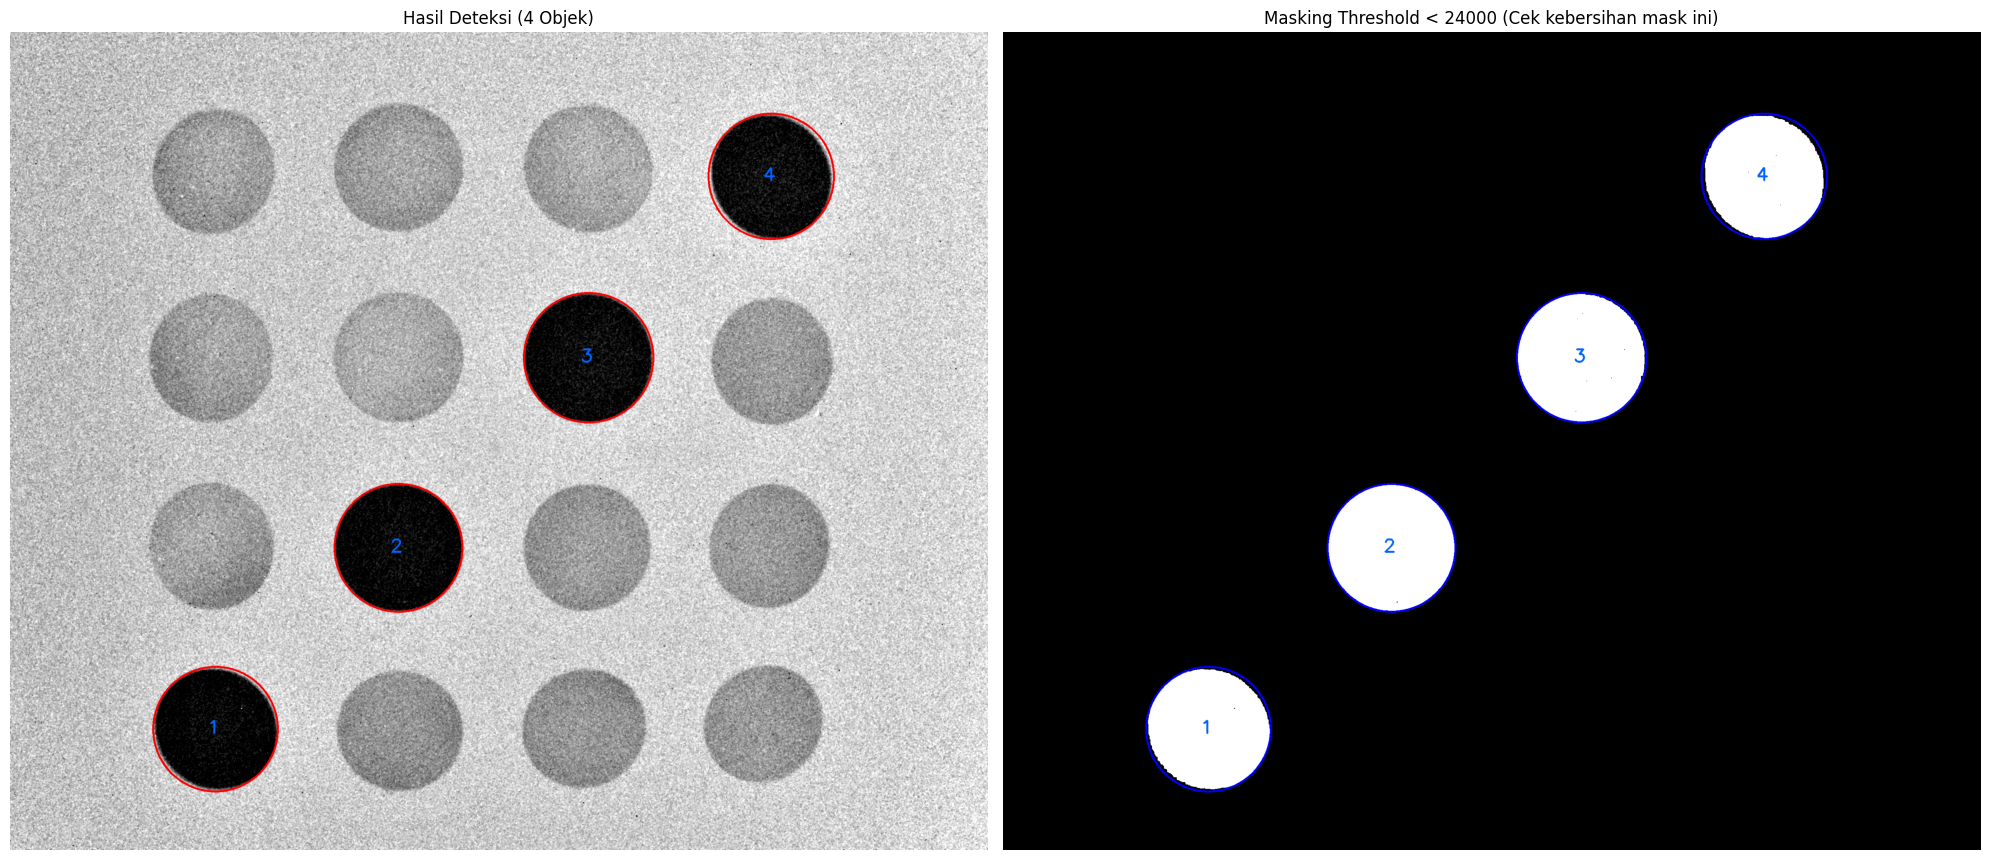

=== Analisis Pola Diagonal ===
Diagonal X: [514, 972, 1448, 1905]
Diagonal Y: [1745, 1291, 815, 361]

X spacing: 463.7px
Y spacing: -461.3px

=== Generate Grid 4x4 ===
X positions (kolom): [514, 977, 1441, 1905]
Y positions (baris): [1745, 1283, 822, 361]

=== Grid 4x4 (16 posisi) ===
[0][0]: (514, 1745)
[0][1]: (977, 1745)
[0][2]: (1441, 1745)
[0][3]: (1905, 1745)
[1][0]: (514, 1283)
[1][1]: (977, 1283)
[1][2]: (1441, 1283)
[1][3]: (1905, 1283)
[2][0]: (514, 822)
[2][1]: (977, 822)
[2][2]: (1441, 822)
[2][3]: (1905, 822)
[3][0]: (514, 361)
[3][1]: (977, 361)
[3][2]: (1441, 361)
[3][3]: (1905, 361)

=== Hasil Grid ===
No   | Grid     | Center              
------------------------------------------------------------
1    | [0,0]  | (514, 1745)         
2    | [0,1]  | (977, 1745)         
3    | [0,2]  | (1441, 1745)        
4    | [0,3]  | (1905, 1745)        
5    | [1,0]  | (514, 1283)         
6    | [1,1]  | (977, 1283)         
7    | [1,2]  | (1441, 1283)        
8    | [1,3]  |

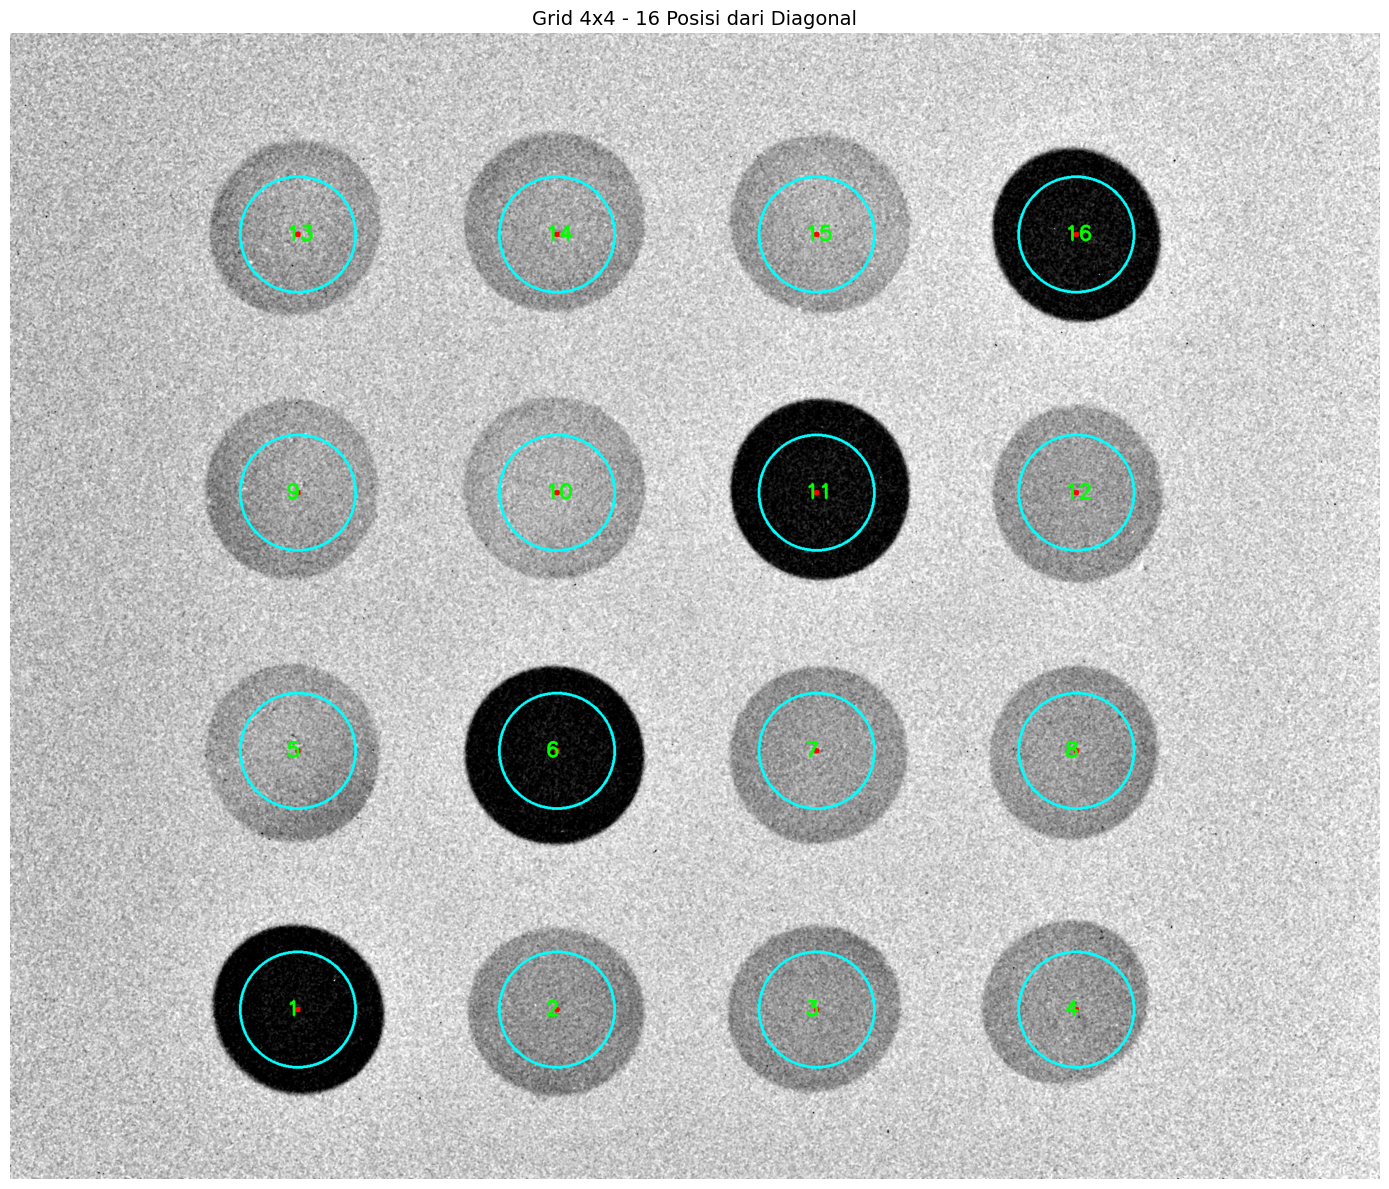

In [ ]:
def detect_grid_from_diagonal(image_path, initial_results, grid_size=4):
    """
    Hitung posisi grid 4x4 lengkap dari diagonal yang sudah terdeteksi.
    TIDAK ada deteksi tambahan, hanya kalkulasi posisi grid.
    """
    # Load gambar untuk visualisasi
    img_16bit = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img_16bit is None:
        print("Error: Gambar tidak ditemukan.")
        return None
    
    circles = initial_results['circles']
    
    # 1. Analisis diagonal
    print("=== Analisis Pola Diagonal ===")
    positions = [(c['center'][0], c['center'][1]) for c in circles]
    
    x_coords = [pos[0] for pos in positions]
    y_coords = [pos[1] for pos in positions]
    
    print("Diagonal X:", x_coords)
    print("Diagonal Y:", y_coords)
    
    # Hitung spacing
    x_spacings = [x_coords[i+1] - x_coords[i] for i in range(len(x_coords)-1)]
    y_spacings = [y_coords[i+1] - y_coords[i] for i in range(len(y_coords)-1)]
    
    mean_x_spacing = np.mean(x_spacings)
    mean_y_spacing = np.mean(y_spacings)
    
    print(f"\nX spacing: {mean_x_spacing:.1f}px")
    print(f"Y spacing: {mean_y_spacing:.1f}px")
    
    # 2. Generate SEMUA posisi grid (16 posisi)
    print("\n=== Generate Grid 4x4 ===")
    
    ref_x, ref_y = positions[0]  # Referensi dari diagonal pertama
    
    # X untuk kolom 0,1,2,3
    x_positions = [int(ref_x + col * mean_x_spacing) for col in range(grid_size)]
    # Y untuk baris 0,1,2,3
    y_positions = [int(ref_y + row * mean_y_spacing) for row in range(grid_size)]
    
    print(f"X positions (kolom): {x_positions}")
    print(f"Y positions (baris): {y_positions}")
    
    # 3. Buat 16 kombinasi
    grid_results = []
    
    print("\n=== Grid 4x4 (16 posisi) ===")
    for row in range(grid_size):
        for col in range(grid_size):
            center_x = x_positions[col]
            center_y = y_positions[row]
            
            grid_results.append({
                'id': row * grid_size + col + 1,
                'grid_pos': (row, col),
                'center': (center_x, center_y),
                'radius': 103  # Dari perhitungan 2/3 * 155
            })
            
            print(f"[{row}][{col}]: ({center_x}, {center_y})")
    
    # 4. Visualisasi
    img_display = cv2.normalize(img_16bit, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')
    img_rgb = cv2.cvtColor(img_display, cv2.COLOR_GRAY2RGB)
    
    print("\n" + "="*60)
    print("=== Hasil Grid ===")
    print("="*60)
    print(f"{'No':<4} | {'Grid':<8} | {'Center':<20}")
    print("-" * 60)
    
    for item in grid_results:
        row, col = item['grid_pos']
        center = item['center']
        
        # Gambar lingkaran di semua posisi
        cv2.circle(img_rgb, center, item['radius'], (0, 255, 255), 3)
        cv2.circle(img_rgb, center, 5, (255, 0, 0), -1)  # Red dot di center
        
        # Label nomor
        cv2.putText(img_rgb, str(item['id']), (center[0]-20, center[1]+10),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)
        
        print(f"{item['id']:<4} | [{row},{col}]  | {str(center):<20}")
    
    print("="*60)
    
    # Tampilkan
    plt.figure(figsize=(14, 12))
    plt.imshow(img_rgb)
    plt.title("Grid 4x4 - 16 Posisi dari Diagonal", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return {
        'grid': grid_results,
        'image': img_rgb,
        'x_spacing': mean_x_spacing,
        'y_spacing': mean_y_spacing,
        'x_positions': x_positions,
        'y_positions': y_positions
    }


# Run
image_file = r"sample-circle.tiff"
initial_results = process_image(image_file, return_data=True)

if initial_results and len(initial_results['circles']) >= 2:
    grid_results = detect_grid_from_diagonal(image_file, initial_results)
else:
    print("Tidak cukup lingkaran terdeteksi untuk analisis diagonal.")

## Histogram Analysis for Each Grid Position

Analyze pixel value distribution for each of the 16 grid positions.

Grid [0,0] at (514, 1745): Mean=2306.5, Median=762.0, Std=3075.6, Range=[0-19834]
Grid [0,1] at (977, 1745): Mean=37898.6, Median=37885.0, Std=4831.5, Range=[14752-65535]
Grid [0,2] at (1441, 1745): Mean=38722.1, Median=38790.0, Std=4798.5, Range=[22010-61961]
Grid [0,3] at (1905, 1745): Mean=39317.1, Median=39340.0, Std=5242.7, Range=[4369-65535]
Grid [1,0] at (514, 1283): Mean=42206.0, Median=42194.0, Std=5356.7, Range=[8738-61155]
Grid [1,1] at (977, 1283): Mean=2789.6, Median=1903.0, Std=3226.2, Range=[0-21076]
Grid [1,2] at (1441, 1283): Mean=40544.0, Median=40595.0, Std=4862.3, Range=[22632-60046]
Grid [1,3] at (1905, 1283): Mean=39930.0, Median=39830.0, Std=4965.2, Range=[17168-57982]
Grid [2,0] at (514, 822): Mean=42181.9, Median=42191.0, Std=5193.6, Range=[22145-64298]
Grid [2,1] at (977, 822): Mean=45456.2, Median=45452.0, Std=4742.7, Range=[27183-64067]
Grid [2,2] at (1441, 822): Mean=3625.0, Median=3123.0, Std=3589.6, Range=[0-25288]
Grid [2,3] at (1905, 822): Mean=40203.0,

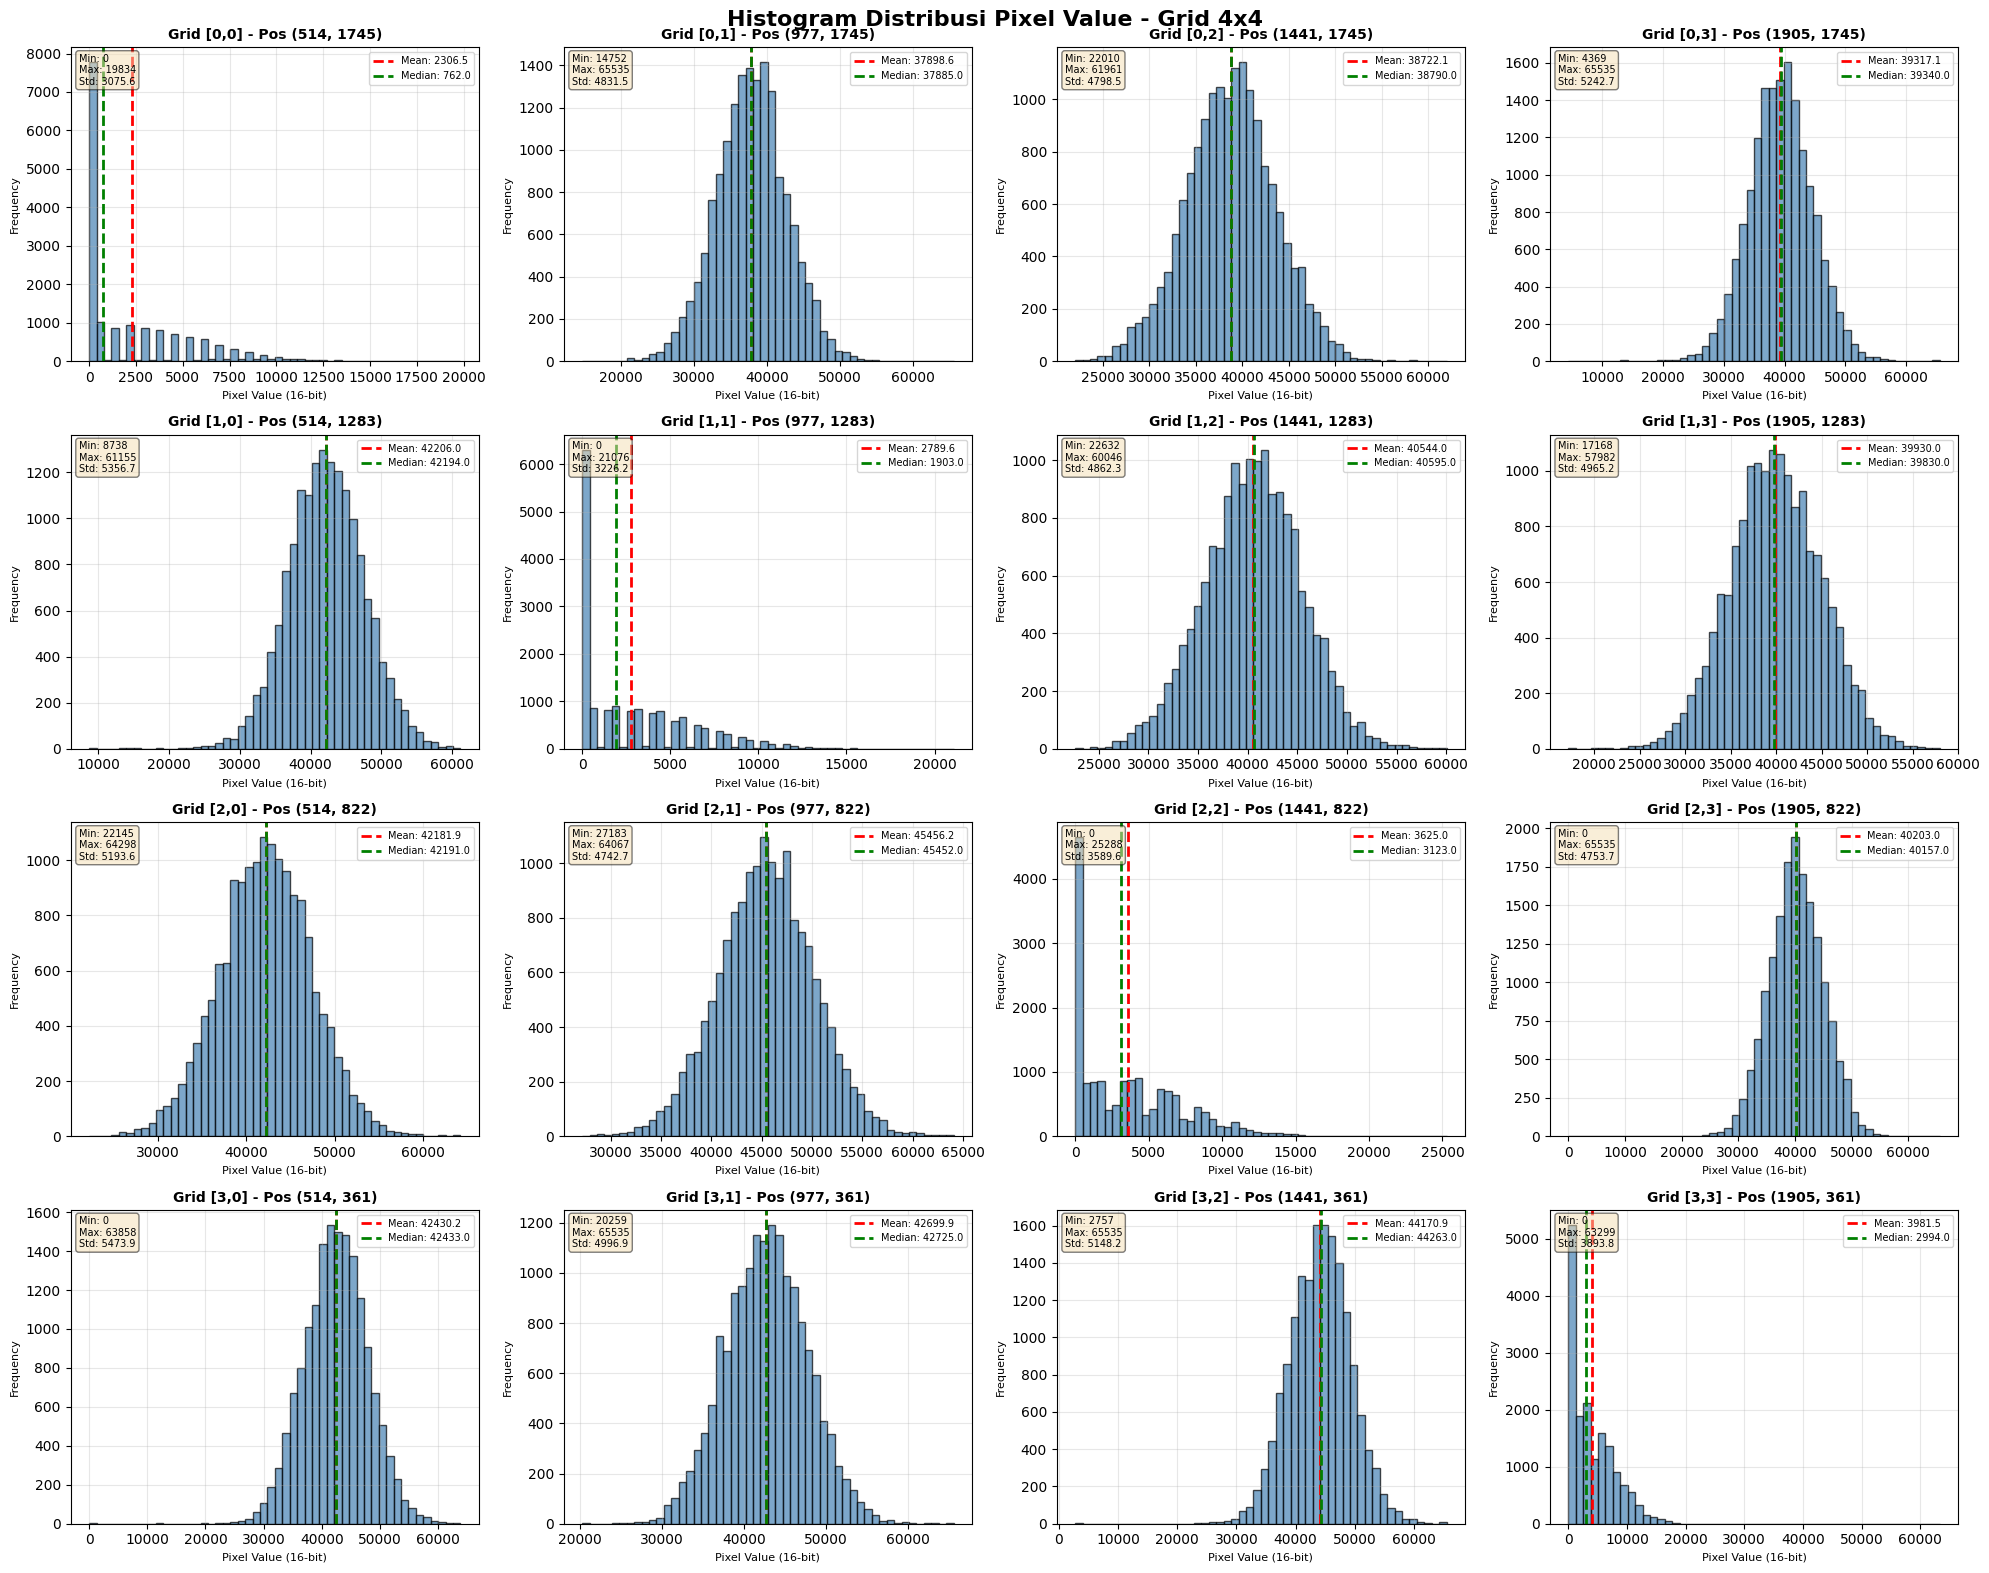

In [11]:
def plot_grid_histograms(image_path, grid_results):
    """
    Plot histogram untuk setiap posisi grid (16 histogram dalam 4x4 layout).
    """
    # Load gambar
    img_16bit = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img_16bit is None:
        print("Error: Gambar tidak ditemukan.")
        return
    
    grid_data = grid_results['grid']
    
    # Setup plot 4x4
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))
    fig.suptitle('Histogram Distribusi Pixel Value - Grid 4x4', fontsize=16, fontweight='bold')
    
    for idx, item in enumerate(grid_data):
        row, col = item['grid_pos']
        center = item['center']
        radius = item['radius']
        
        # Buat mask untuk area lingkaran
        mask = np.zeros_like(img_16bit, dtype=np.uint8)
        cv2.circle(mask, center, int(radius * 0.7), 255, -1)
        
        # Ekstrak pixel values di dalam lingkaran
        pixel_values = img_16bit[mask == 255]
        
        # Hitung statistik
        mean_val = np.mean(pixel_values)
        median_val = np.median(pixel_values)
        std_val = np.std(pixel_values)
        min_val = np.min(pixel_values)
        max_val = np.max(pixel_values)
        
        # Plot histogram di subplot yang sesuai
        ax = axes[row, col]
        ax.hist(pixel_values, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
        
        # Tambahkan garis mean dan median
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
        
        # Title dan label
        ax.set_title(f'Grid [{row},{col}] - Pos {center}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Pixel Value (16-bit)', fontsize=8)
        ax.set_ylabel('Frequency', fontsize=8)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)
        
        # Tambahkan text box dengan statistik
        stats_text = f'Min: {min_val:.0f}\nMax: {max_val:.0f}\nStd: {std_val:.1f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                fontsize=7, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        print(f"Grid [{row},{col}] at {center}: Mean={mean_val:.1f}, Median={median_val:.1f}, Std={std_val:.1f}, Range=[{min_val}-{max_val}]")
    
    plt.tight_layout()
    plt.show()


# Run histogram analysis
if 'grid_results' in locals():
    plot_grid_histograms(image_file, grid_results)
else:
    print("Run the grid detection cell first!")

## Compare Diagonal Statistics

Compare mean and median values between lower diagonal (main diagonal) and upper diagonal.

=== DIAGONAL COMPARISON ===

--- LOWER DIAGONAL: [1,0], [2,0], [2,1], [3,0], [3,1], [3,2] ---
Grid       | Center           | Mean       | Median     | Std       
--------------------------------------------------------------------------------
(1, 0)     | (514, 1283)      | 42206.0    | 42194.0    | 5356.7    
(2, 0)     | (514, 822)       | 42181.9    | 42191.0    | 5193.6    
(2, 1)     | (977, 822)       | 45456.2    | 45452.0    | 4742.7    
(3, 0)     | (514, 361)       | 42430.2    | 42433.0    | 5473.9    
(3, 1)     | (977, 361)       | 42699.9    | 42725.0    | 4996.9    
(3, 2)     | (1441, 361)      | 44170.9    | 44263.0    | 5148.2    

Average Mean: 43190.9
Average Median: 43209.7
Std of Means: 1217.9

--- UPPER DIAGONAL: [0,1], [0,2], [0,3], [1,2], [1,3], [2,3] ---
Grid       | Center           | Mean       | Median     | Std       
--------------------------------------------------------------------------------
(0, 1)     | (977, 1745)      | 37898.6    | 37885.0    | 

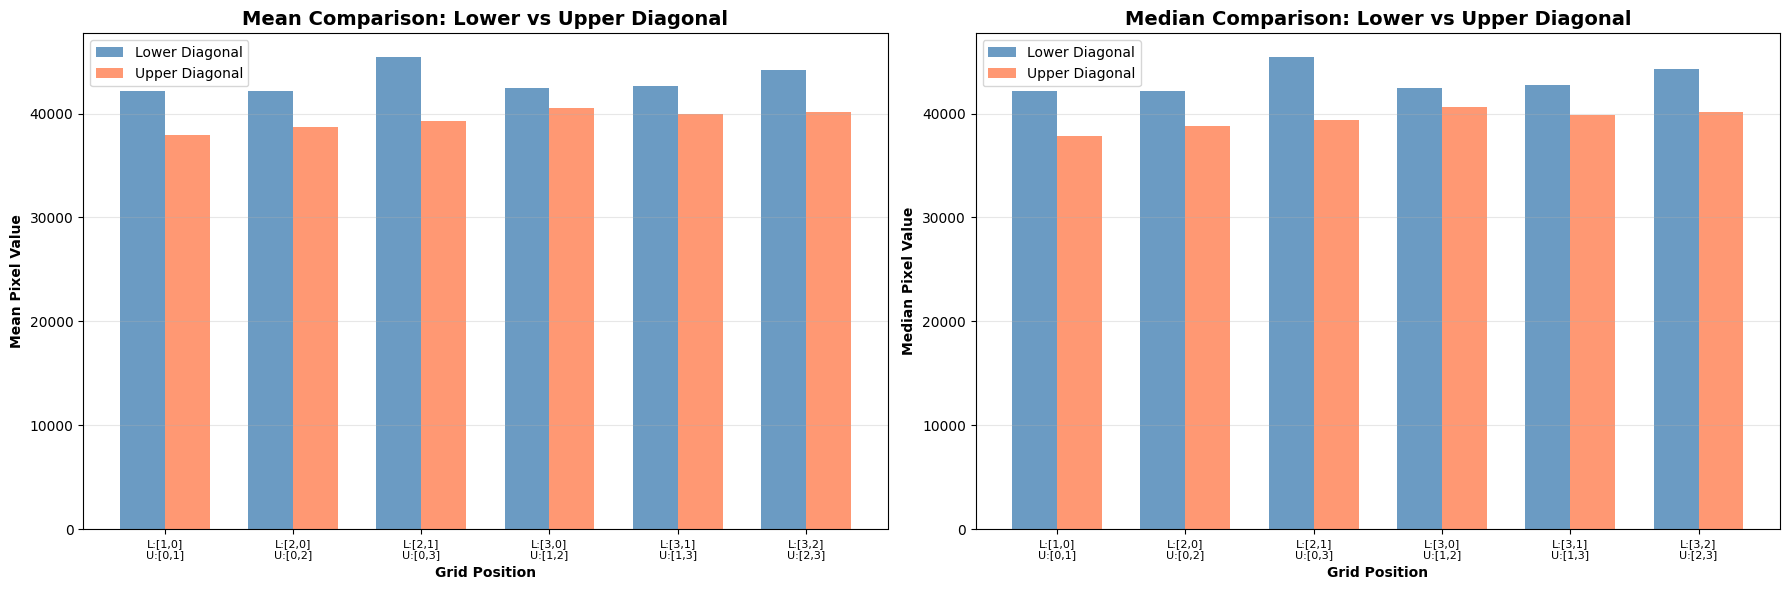

In [12]:
def compare_diagonals(image_path, grid_results):
    """
    Bandingkan statistik antara lower diagonal dan upper diagonal.
    Lower diagonal: [1,0], [2,0], [2,1], [3,0], [3,1], [3,2]
    Upper diagonal: [0,1], [0,2], [0,3], [1,2], [1,3], [2,3]
    """
    # Load gambar
    img_16bit = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img_16bit is None:
        print("Error: Gambar tidak ditemukan.")
        return
    
    grid_data = grid_results['grid']
    
    # Identifikasi lower dan upper diagonal
    lower_positions = [(1,0), (2,0), (2,1), (3,0), (3,1), (3,2)]
    upper_positions = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
    
    lower_diagonal = []
    upper_diagonal = []
    
    for item in grid_data:
        row, col = item['grid_pos']
        
        if (row, col) in lower_positions:
            lower_diagonal.append(item)
        elif (row, col) in upper_positions:
            upper_diagonal.append(item)
    
    # Hitung statistik untuk setiap diagonal
    def get_diagonal_stats(diagonal_items):
        stats = []
        for item in diagonal_items:
            center = item['center']
            radius = item['radius']
            row, col = item['grid_pos']
            
            # Buat mask
            mask = np.zeros_like(img_16bit, dtype=np.uint8)
            cv2.circle(mask, center, int(radius * 0.7), 255, -1)
            
            # Ekstrak pixel values
            pixel_values = img_16bit[mask == 255]
            
            mean_val = np.mean(pixel_values)
            median_val = np.median(pixel_values)
            std_val = np.std(pixel_values)
            
            stats.append({
                'grid_pos': (row, col),
                'center': center,
                'mean': mean_val,
                'median': median_val,
                'std': std_val,
                'pixel_count': len(pixel_values)
            })
        
        return stats
    
    lower_stats = get_diagonal_stats(lower_diagonal)
    upper_stats = get_diagonal_stats(upper_diagonal)
    
    # Print comparison
    print("="*80)
    print("=== DIAGONAL COMPARISON ===")
    print("="*80)
    
    print("\n--- LOWER DIAGONAL: [1,0], [2,0], [2,1], [3,0], [3,1], [3,2] ---")
    print(f"{'Grid':<10} | {'Center':<16} | {'Mean':<10} | {'Median':<10} | {'Std':<10}")
    print("-"*80)
    for s in lower_stats:
        print(f"{str(s['grid_pos']):<10} | {str(s['center']):<16} | {s['mean']:<10.1f} | {s['median']:<10.1f} | {s['std']:<10.1f}")
    
    lower_means = [s['mean'] for s in lower_stats]
    lower_medians = [s['median'] for s in lower_stats]
    print(f"\nAverage Mean: {np.mean(lower_means):.1f}")
    print(f"Average Median: {np.mean(lower_medians):.1f}")
    print(f"Std of Means: {np.std(lower_means):.1f}")
    
    print("\n--- UPPER DIAGONAL: [0,1], [0,2], [0,3], [1,2], [1,3], [2,3] ---")
    print(f"{'Grid':<10} | {'Center':<16} | {'Mean':<10} | {'Median':<10} | {'Std':<10}")
    print("-"*80)
    for s in upper_stats:
        print(f"{str(s['grid_pos']):<10} | {str(s['center']):<16} | {s['mean']:<10.1f} | {s['median']:<10.1f} | {s['std']:<10.1f}")
    
    upper_means = [s['mean'] for s in upper_stats]
    upper_medians = [s['median'] for s in upper_stats]
    print(f"\nAverage Mean: {np.mean(upper_means):.1f}")
    print(f"Average Median: {np.mean(upper_medians):.1f}")
    print(f"Std of Means: {np.std(upper_means):.1f}")
    
    # Summary comparison
    print("\n" + "="*80)
    print("=== SUMMARY ===")
    print("="*80)
    print(f"{'Metric':<30} | {'Lower Diagonal':<20} | {'Upper Diagonal':<20}")
    print("-"*80)
    print(f"{'Average Mean':<30} | {np.mean(lower_means):<20.1f} | {np.mean(upper_means):<20.1f}")
    print(f"{'Average Median':<30} | {np.mean(lower_medians):<20.1f} | {np.mean(upper_medians):<20.1f}")
    print(f"{'Std of Means':<30} | {np.std(lower_means):<20.1f} | {np.std(upper_means):<20.1f}")
    print(f"{'Mean Difference':<30} | {abs(np.mean(lower_means) - np.mean(upper_means)):<20.1f} |")
    print("="*80)
    
    # Visualisasi bar chart perbandingan
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Plot 1: Mean comparison
    ax1 = axes[0]
    x_lower = np.arange(len(lower_means))
    x_upper = np.arange(len(upper_means))
    width = 0.35
    
    ax1.bar(x_lower - width/2, lower_means, width, label='Lower Diagonal', color='steelblue', alpha=0.8)
    ax1.bar(x_upper + width/2, upper_means, width, label='Upper Diagonal', color='coral', alpha=0.8)
    
    ax1.set_xlabel('Grid Position', fontweight='bold')
    ax1.set_ylabel('Mean Pixel Value', fontweight='bold')
    ax1.set_title('Mean Comparison: Lower vs Upper Diagonal', fontweight='bold', fontsize=14)
    ax1.set_xticks(np.arange(6))
    
    # Create labels from actual grid positions
    lower_labels = [f"[{s['grid_pos'][0]},{s['grid_pos'][1]}]" for s in lower_stats]
    upper_labels = [f"[{s['grid_pos'][0]},{s['grid_pos'][1]}]" for s in upper_stats]
    combined_labels = [f"L:{lower_labels[i]}\nU:{upper_labels[i]}" for i in range(6)]
    
    ax1.set_xticklabels(combined_labels, fontsize=8)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Median comparison
    ax2 = axes[1]
    ax2.bar(x_lower - width/2, lower_medians, width, label='Lower Diagonal', color='steelblue', alpha=0.8)
    ax2.bar(x_upper + width/2, upper_medians, width, label='Upper Diagonal', color='coral', alpha=0.8)
    
    ax2.set_xlabel('Grid Position', fontweight='bold')
    ax2.set_ylabel('Median Pixel Value', fontweight='bold')
    ax2.set_title('Median Comparison: Lower vs Upper Diagonal', fontweight='bold', fontsize=14)
    ax2.set_xticks(np.arange(6))
    ax2.set_xticklabels(combined_labels, fontsize=8)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


# Run diagonal comparison
if 'grid_results' in locals():
    compare_diagonals(image_file, grid_results)
else:
    print("Run the grid detection cell first!")